# <div align="center"><u>Project 4 - k Means Clustering</u>

##############################################################################################################################

###  Import libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

### Suppress warnings

In [44]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [45]:
# Start time
start_time = time.time()

### Load the final dataset and store it within a pandas DataFrame

In [46]:
# Load the final dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\VAVOULIDIS MILTIADIS - ZACHARIAS\Projects\Project 4\final_dataset.csv")

# Print the dataset
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,V29,V30,Class
0,1.176800,-2.121200,1.357375,1.184085,1.618861,2.541404,2.647422,2.620973,2.348535,2.511708,...,-1.375159,2.439568,2.287627,1.344848,2.641905,2.246192,2.296076,2.443918,2.225247,2
1,1.949929,-0.354875,1.795991,2.249396,-0.842995,-0.498189,-0.000497,0.574944,0.017882,-0.925449,...,-0.370048,1.631542,2.287627,-0.377098,-0.443388,-0.137634,1.087084,-0.234408,0.355314,2
2,1.686226,0.476899,1.670052,1.846217,0.975239,1.148680,1.496076,2.110330,1.004666,-0.407692,...,-0.019582,1.434234,1.807751,0.546654,1.223448,0.920718,1.955000,1.369057,0.265197,2
3,-0.791983,0.268955,-0.606410,-0.831485,2.737521,2.541404,2.091997,1.506601,2.521318,2.517947,...,0.140773,-0.245395,-0.593838,2.595949,2.641905,2.119474,2.175786,2.443918,2.482456,2
4,1.866023,-1.174698,1.891531,2.154338,0.295047,0.599453,1.504202,1.482665,0.006363,-0.588595,...,-1.484267,1.424838,1.525780,0.232758,-0.314469,0.665254,0.729259,-0.951602,-0.410683,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.246595,0.749377,2.191180,2.250380,1.077633,0.256947,2.125856,2.402886,-0.312326,-0.994068,...,0.124241,1.860170,2.287627,0.394190,-0.270329,0.719489,1.629151,-1.516438,-0.763016,2
565,1.818077,2.150007,1.722165,2.036334,0.112199,0.003614,0.772845,1.312717,-0.212495,-1.134424,...,2.083216,1.512531,1.854045,-0.699963,-0.404152,0.267358,0.733827,-0.565135,-1.062155,2
566,0.760269,2.109375,0.727678,0.715676,-0.856891,-0.018680,0.075483,0.118824,-0.834515,-0.955080,...,1.400468,0.626208,0.576760,-0.821037,0.417005,0.362650,0.414069,-1.222872,-0.321817,2
567,1.958919,2.408144,2.108668,2.049446,1.574978,2.541404,2.647422,2.751293,2.264063,1.178328,...,2.276634,2.439568,2.043428,1.470406,2.641905,2.619251,2.289985,2.249756,2.482456,2


### Split features and true label

In [47]:
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column ("Class")

### Set n_init parameter for fine tuning

In [48]:
# Define the range of n_init values you want to test
n_init_values = [1, 2, 5, 10, 15, 20, 30, 50]

# Initialize lists to store the scores
ari_scores = []
nmi_scores = []

### Apply K-Means and save ARI and NMI for each run

In [49]:
# Loop through each n_init value
for n in n_init_values:
    # Apply K-Means with the current n_init
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=n)
    clusters = kmeans.fit_predict(X)
    
    # Calculate scores (evaluate clustering in proper scientific way)
    ari = adjusted_rand_score(y, clusters)
    nmi = normalized_mutual_info_score(y, clusters)
    
    # Append to lists
    ari_scores.append(ari)
    nmi_scores.append(nmi)
    
    # Optional: Print progress
    print(f"n_init: {n:2d} | ARI: {ari:.4f} | NMI: {nmi:.4f}")

n_init:  1 | ARI: 0.6767 | NMI: 0.5587
n_init:  2 | ARI: 0.6767 | NMI: 0.5587
n_init:  5 | ARI: 0.6767 | NMI: 0.5587
n_init: 10 | ARI: 0.6767 | NMI: 0.5587
n_init: 15 | ARI: 0.6767 | NMI: 0.5587
n_init: 20 | ARI: 0.6767 | NMI: 0.5587
n_init: 30 | ARI: 0.6767 | NMI: 0.5587
n_init: 50 | ARI: 0.6767 | NMI: 0.5587


### Plot the results for tuning the "n_init" parameter

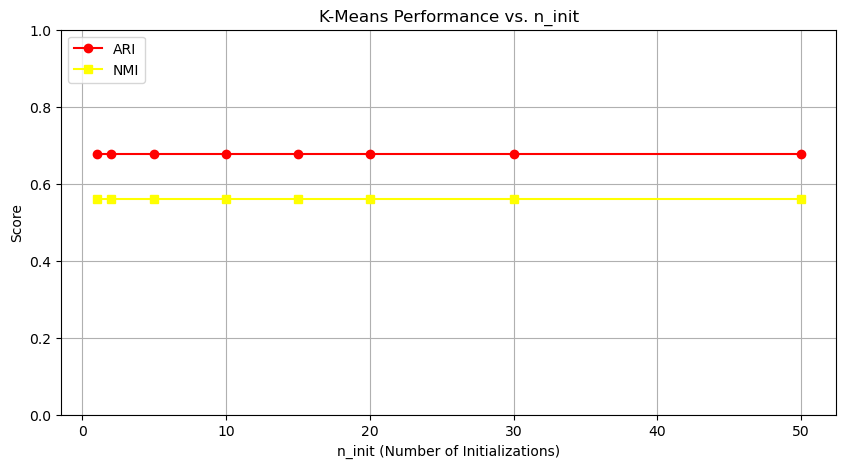

In [50]:
# Plot the results to find the sweet spot
plt.figure(figsize=(10, 5))
plt.plot(n_init_values, ari_scores, marker='o', label='ARI', color='red')
plt.plot(n_init_values, nmi_scores, marker='s', label='NMI', color='yellow')

plt.title('K-Means Performance vs. n_init')
plt.xlabel('n_init (Number of Initializations)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

### End time

In [51]:
# End time
end_time = time.time()

### Elapsed time

In [52]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for k Means Clustering fine tuning: {elapsed_time:.2f} seconds")

Elapsed time for k Means Clustering fine tuning: 12.56 seconds


### Start time

In [53]:
# Start time
start_time = time.time()

In [54]:
### Apply K-Means for the specific model

In [55]:
# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=1)
clusters = kmeans.fit_predict(X)

### Evaluate clustering

In [56]:
 # Calculate scores (evaluate clustering in proper scientific way)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

In [57]:
print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.6766977462320126
NMI: 0.5586701342379229


### End time

In [58]:
# End time
end_time = time.time()

### Elapsed time

In [59]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for k Means Clustering model: {elapsed_time:.2f} seconds")

Elapsed time for k Means Clustering model: 0.18 seconds
